# Curating samples from the xView 

- sample from promising images
- 


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [116]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geom_utils as sgut

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data/xView-train_images-subset/'
label_file = '../../xView_train.geojson'

In [4]:
labelnames_di = {
    11:'Fixed-wing Aircraft', 12:'Small Aircraft', 13:'Passenger/Cargo Plane', 15:'Helicopter',
    17:'Passenger Vehicle', 18:'Small Car', 19:'Bus', 20:'Pickup Truck', 21:'Utility Truck',
    23:'Truck', 24:'Cargo Truck', 25:'Truck Tractor w/ Box Trailer', 26:'Truck Tractor',27:'Trailer',
    28:'Truck Tractor w/ Flatbed Trailer', 29:'Truck Tractor w/ Liquid Tank', 32:'Crane Truck',
    33:'Railway Vehicle', 34:'Passenger Car', 35:'Cargo/Container Car', 36:'Flat Car', 37:'Tank car',
    38:'Locomotive', 40:'Maritime Vessel', 41:'Motorboat', 42:'Sailboat', 44:'Tugboat', 45:'Barge',
    47:'Fishing Vessel', 49:'Ferry', 50:'Yacht', 51:'Container Ship', 52:'Oil Tanker',
    53:'Engineering Vehicle', 54:'Tower crane', 55:'Container Crane', 56:'Reach Stacker',
    57:'Straddle Carrier', 59:'Mobile Crane', 60:'Dump Truck', 61:'Haul Truck', 62:'Scraper/Tractor',
    63:'Front loader/Bulldozer', 64:'Excavator', 65:'Cement Mixer', 66:'Ground Grader', 71:'Hut/Tent',
    72:'Shed', 73:'Building', 74:'Aircraft Hangar', 76:'Damaged Building', 77:'Facility', 79:'Construction Site',
    83:'Vehicle Lot', 84:'Helipad', 86:'Storage Tank', 89:'Shipping container lot', 91:'Shipping Container',
    93:'Pylon', 94:'Tower'}
labelnames_di_ = {v:k for k,v in labelnames_di.items()}

In [128]:
def sample_xy( image_, num_samp, res= 128, seed= 11):
    # NOTE: sampling is in numpy coordinates
    res_half = int( res/2)
    shift_min = int( res/10)
    xmax, ymax, _ = image_.shape
    np.random.seed( seed)
    # sample valid x and y coordinates (at least half-resolution away from edge):
    xs = res_half + np.random.uniform( xmax - res_half, size= num_samp).astype( int)
    ys = res_half + np.random.uniform( ymax - res_half, size= num_samp).astype( int)
    dfs = pd.DataFrame( {'xs': xs, 'ys': ys}).sort_values( by= 'xs')
    # we don't want to sample points that are too close:
    to_check = np.argwhere( abs( ( dfs['xs'] - np.roll( dfs['xs'], shift= 1))) < shift_min).reshape(-1)
    to_drop = []
    for index in to_check:
        if abs( dfs.iloc[[index-1,index]]['ys'].diff().values[-1]) < shift_min:
            print(f'Removing as too close: {dfs.iloc[[index-1]].values} and {dfs.iloc[[index]].values}')
            to_drop.append( dfs.iloc[[index]].index[0])
    dfs.drop( labels= to_drop, axis= 0, inplace= True)
    return dfs

## Investigate data, try things out 

_**you can even add fancy markdown throughout to document things..?**_

In [121]:
label_li = sduti.from_json( label_file)['features']
df = pd.DataFrame([x['properties'] for x in label_li])
df.drop(
    labels= ['edited_by','cat_id','point_geom','grid_file','ingest_time'], axis= 1, inplace= True
)
df['cat'] = df['type_id'].map( labelnames_di)
df['bbox'] = df['bounds_imcoords'].map( lambda x: [int(y) for y in x.split(',')])
df['bbox_np'] = df['bbox'].map( sgut.bbox_np)
df.head(3)

,bounds_imcoords,type_id,index_right,image_id,feature_id,cat,bbox,bbox_np
0,"2712,1145,2746,1177",73,2356,2355.tif,374410,Building,"[2712, 1145, 2746, 1177]","(1145, 2712, 1177, 2746)"
1,"2720,2233,2760,2288",73,2356,2355.tif,394393,Building,"[2720, 2233, 2760, 2288]","(2233, 2720, 2288, 2760)"
2,"2687,1338,2740,1399",73,2356,2355.tif,374031,Building,"[2687, 1338, 2740, 1399]","(1338, 2687, 1399, 2740)"


In [6]:
dfg = df.groupby('image_id').agg(
    {
        'type_id': [ 
            len, lambda x: len(set(x)), 
            lambda x: len([y for y in x if y == 18]),
            lambda x: len([y for y in x if y == 73])
        ]
    }
).droplevel(level=0,axis=1).rename( 
    columns= {'<lambda_0>': 'n_cats', 'len': 'n_labels', '<lambda_1>':'n_cars', '<lambda_2>':'n_buildings'}
)
dfg.head(3)

,n_labels,n_cats,n_cars,n_buildings
image_id,,,,
10.tif,63,7,2,44
100.tif,135,3,62,66
102.tif,1965,9,345,1563


In [112]:
target_ims = dfg.loc[ dfg['n_cars']>300].index.tolist()
target_ims = [x for x in target_ims if os.path.exists(f'{data_path}{x}')]
print(f'{len(target_ims)} images')

180 images


In [8]:
target_ims = [x for x in target_ims if os.path.exists(f'{data_path}{x}')]

In [123]:
sample_im_name = target_ims[0]
df_ = df.loc[ df['image_id']== sample_im_name]
image_ = sduti.to_numpy( sduti.load_image( f'{data_path}{sample_im_name}'))
xmax, ymax, _ = image_.shape
figsize = ( int(xmax / 200), int( ymax/ 200))
sample_im_name

'102.tif'

In [124]:
dfs = sample_xy( image_, 200, seed= 13)
dfs.shape

Removing as too close: [[ 473 2572]] and [[ 476 2570]]
Removing as too close: [[1371 1319]] and [[1377 1330]]


(198, 2)

In [144]:
samp_bbox_np, _ = sgut.center_on_bbox( (dfs['xs'].values[0],dfs['ys'].values[0],dfs['xs'].values[0],dfs['ys'].values[0]), 128, xmax, ymax)

In [148]:
samp_context_np, samp_bbox_np_ = sgut.center_on_bbox( samp_bbox_np, 256, xmax, ymax, fix_edge= True)

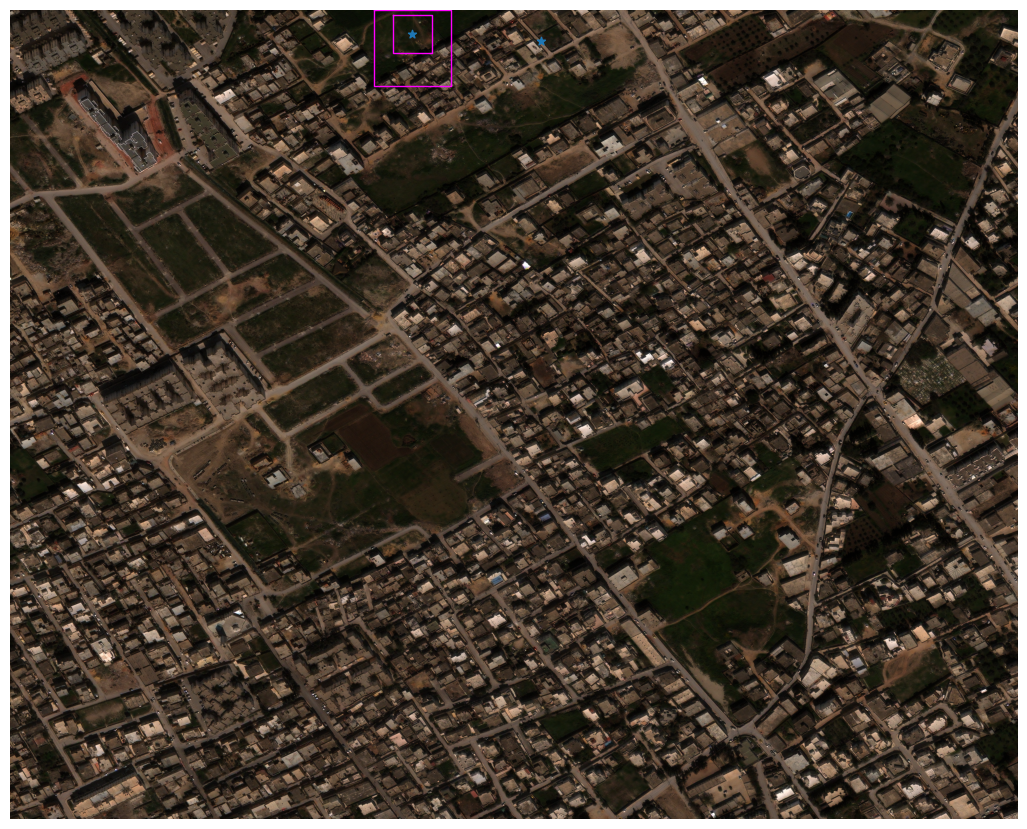

In [150]:
#x_samp, y_samp = np.random.uniform( xmax, size=1000).astype(int), np.random.uniform( ymax, size=1000).astype(int)

ax = splot.plot_single(image_, figsize= figsize)
ax.scatter(dfs['ys'].values[:2], dfs['xs'].values[:2], marker='*')
splo.plot_bbox( *sgut.bbox_np(samp_bbox_np), ax= ax)
splo.plot_bbox( *sgut.bbox_np(samp_context_np), ax= ax)

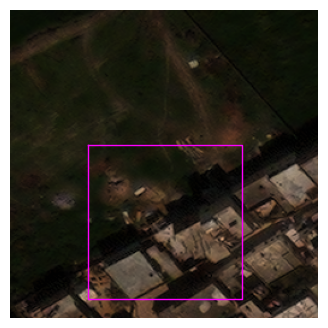

In [149]:
ax = splo.plot_single(
    sgut.crop_to_bbox( image_, samp_context_np), figsize= (4,4)
)
splo.plot_bbox( *sgut.bbox_np(samp_bbox_np_), ax= ax)

Took 0.09650110006332398 mins. Output 931 images


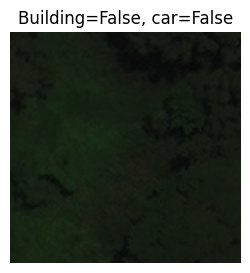

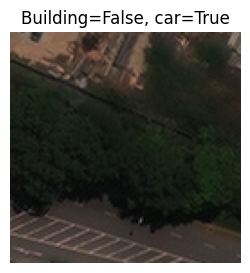

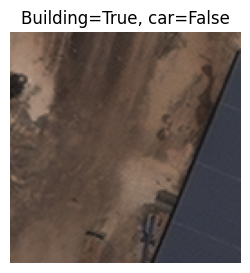

In [235]:
start_ = tm.time()

res = 128
too_close = []
wrong_shape = []
for ii in range(len( x_samp)):
    x, y = x_samp[ii], y_samp[ii]
    
    samp_bbox, _ = center_on_bbox( (x,y,x,y), res, xmax, ymax)
    if samp_bbox is not None:
        samp_image_ = crop_to_bbox( image_, samp_bbox)
        try:
            assert samp_image_.shape == ( res, res, 3)
            samp_labels = set(
                df_.loc[ df_['bbox'].apply( lambda x: intersect( samp_bbox, x)) == True, 'type_id']
            )
            build_flag = 73 in samp_labels
            car_flag = len( samp_labels & set([18])) > 0
            out_name_ = sample_im_name.replace('.tif',f'_{ii}.png')
            out_path_ = f'../data/xView-train_samples-test/{out_name_}'
            #Image.fromarray( crop_to_bbox( image_, samp_bbox)).save( out_path_)
            if ii < 3:  
                ax = splot.plot_single( crop_to_bbox( image_, samp_bbox), figsize= (3,3))
                ax.set_title(f'Building={build_flag}, car={car_flag}')
        except AssertionError:
            wrong_shape.append(ii)#splot.plot_single( )
    else:
        too_close.append(ii)

print(f'Took {(tm.time()-start_)/60} mins. Output {len(x_samp)-len(too_close)} images')

In [236]:
len(too_close), len(wrong_shape)

(69, 0)

In [215]:
len(too_close), len(wrong_shape)

(89, 117)